C:\Users\Asus\AppData\Local\Temp\ipykernel_1108\2319421298.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_1108\2319421298.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_1108\2319421298.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


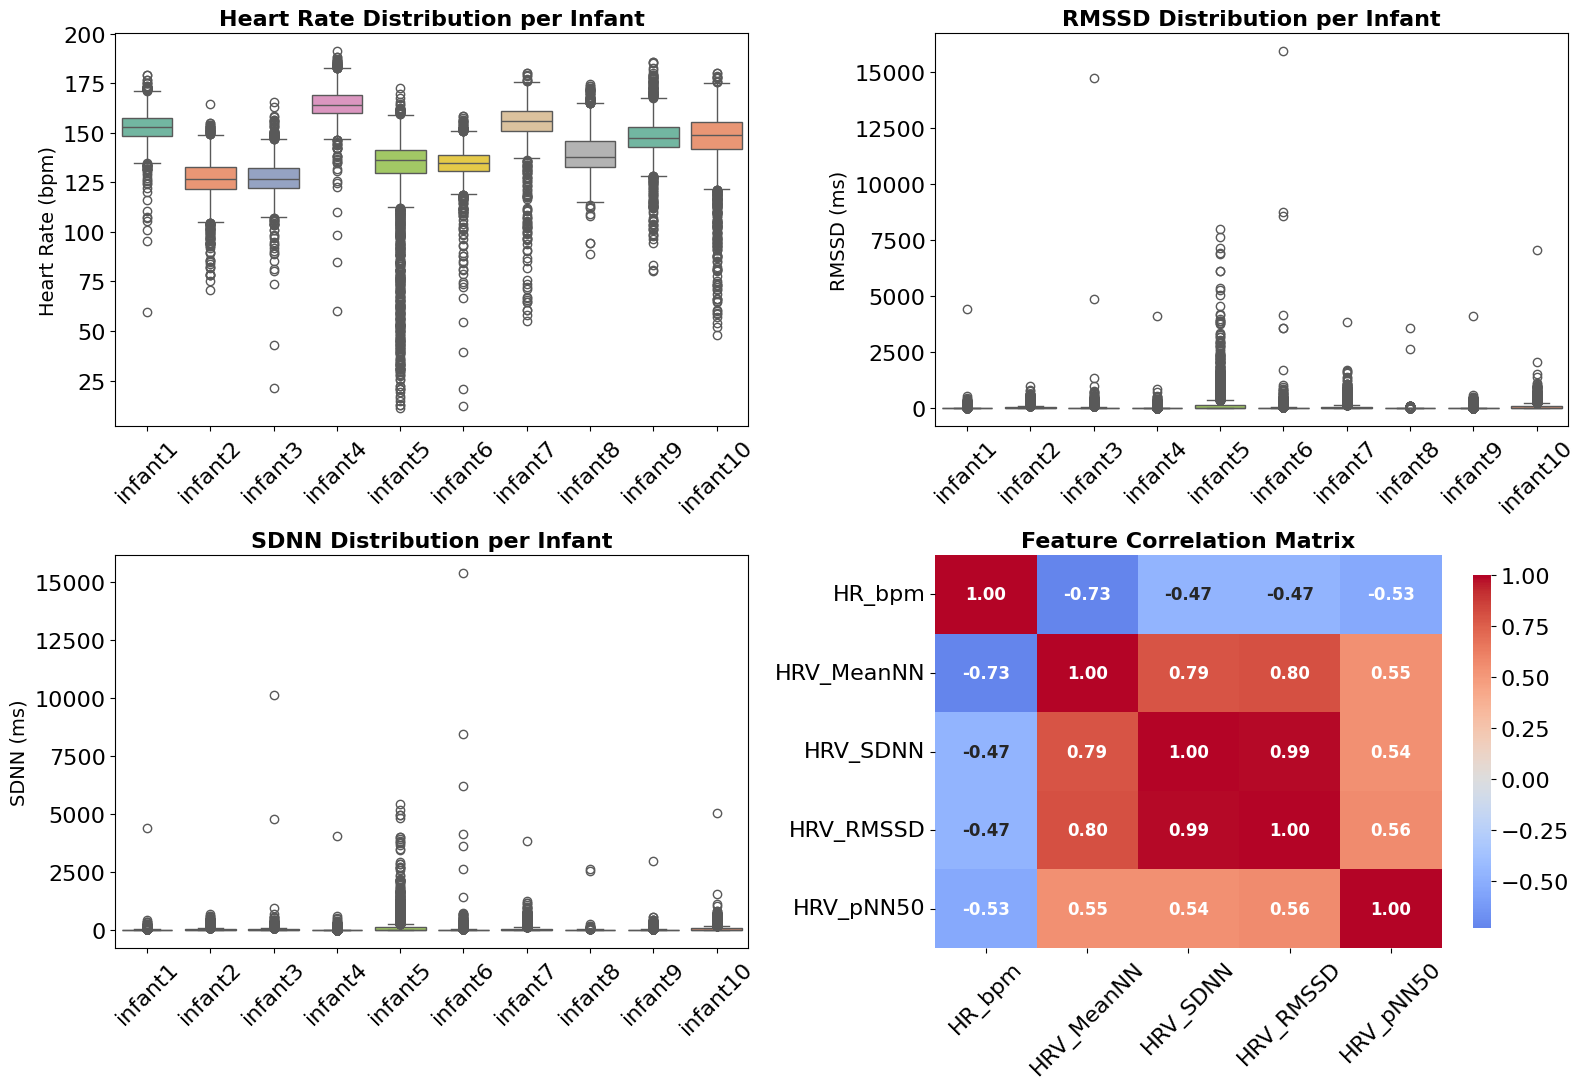

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined_df = pd.read_csv(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\all_infants_hrv_features.csv'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# -----------------------------
# 1. Heart Rate Distribution
# -----------------------------
combined_df['HR_bpm'] = 60000 / combined_df['HRV_MeanNN']

sns.boxplot(
    data=combined_df,
    x='infant_id',
    y='HR_bpm',
    ax=axes[0,0],
    palette='Set2'
)

axes[0,0].set_title(
    'Heart Rate Distribution per Infant',
    fontsize=16,
    fontweight='bold'
)
axes[0,0].set_xlabel('', fontsize=14)
axes[0,0].set_ylabel('Heart Rate (bpm)', fontsize=14)

axes[0,0].tick_params(axis='x', rotation=45, labelsize=16)
axes[0,0].tick_params(axis='y', labelsize=16)

# -----------------------------
# 2. RMSSD Distribution
# -----------------------------
sns.boxplot(
    data=combined_df,
    x='infant_id',
    y='HRV_RMSSD',
    ax=axes[0,1],
    palette='Set2'
)

axes[0,1].set_title(
    'RMSSD Distribution per Infant',
    fontsize=16,
    fontweight='bold'
)
axes[0,1].set_xlabel('', fontsize=14)
axes[0,1].set_ylabel('RMSSD (ms)', fontsize=14)

axes[0,1].tick_params(axis='x', rotation=45, labelsize=16)
axes[0,1].tick_params(axis='y', labelsize=16)

# -----------------------------
# 3. SDNN Distribution
# -----------------------------
sns.boxplot(
    data=combined_df,
    x='infant_id',
    y='HRV_SDNN',
    ax=axes[1,0],
    palette='Set2'
)

axes[1,0].set_title(
    'SDNN Distribution per Infant',
    fontsize=16,
    fontweight='bold'
)
axes[1,0].set_xlabel('', fontsize=14)
axes[1,0].set_ylabel('SDNN (ms)', fontsize=14)

axes[1,0].tick_params(axis='x', rotation=45, labelsize=16)
axes[1,0].tick_params(axis='y', labelsize=16)

# -----------------------------
# 4. Correlation Matrix
# -----------------------------
corr_cols = [
    'HR_bpm',
    'HRV_MeanNN',
    'HRV_SDNN',
    'HRV_RMSSD',
    'HRV_pNN50'
]

corr = combined_df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'fontsize':12, 'fontweight':'bold'},
    cbar_kws={'shrink':0.9},
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Feature Correlation Matrix',
    fontsize=16,
    fontweight='bold'
)

axes[1,1].tick_params(axis='x', rotation=45, labelsize=16)
axes[1,1].tick_params(axis='y', rotation=0, labelsize=16)

# Increase colorbar tick size
cbar = axes[1,1].collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

plt.tight_layout()

plt.savefig(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\cross_infant_eda_new.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [2]:
# Remove artifact windows — RMSSD above 500ms is physiologically impossible
# for a preterm infant and indicates signal corruption
before = len(combined_df)
combined_df_clean = combined_df[combined_df['HRV_RMSSD'] < 500].copy()
after = len(combined_df_clean)

print(f"Windows before cleaning: {before}")
print(f"Windows removed (artifact): {before - after}")
print(f"Windows after cleaning: {after}")
print(f"\nPer infant after cleaning:")
print(combined_df_clean['infant_id'].value_counts().sort_index())

# Save the cleaned version
combined_df_clean.to_csv(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\all_infants_hrv_features_clean.csv',
    index=False
)
print("\nClean feature matrix saved.")

Windows before cleaning: 26208
Windows removed (artifact): 563
Windows after cleaning: 25645

Per infant after cleaning:
infant_id
infant1     2726
infant10    2736
infant2     2574
infant3     2570
infant4     2798
infant5     2553
infant6     2888
infant7     1136
infant8     1460
infant9     4204
Name: count, dtype: int64

Clean feature matrix saved.


C:\Users\Asus\AppData\Local\Temp\ipykernel_1108\662448166.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_1108\662448166.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Asus\AppData\Local\Temp\ipykernel_1108\662448166.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


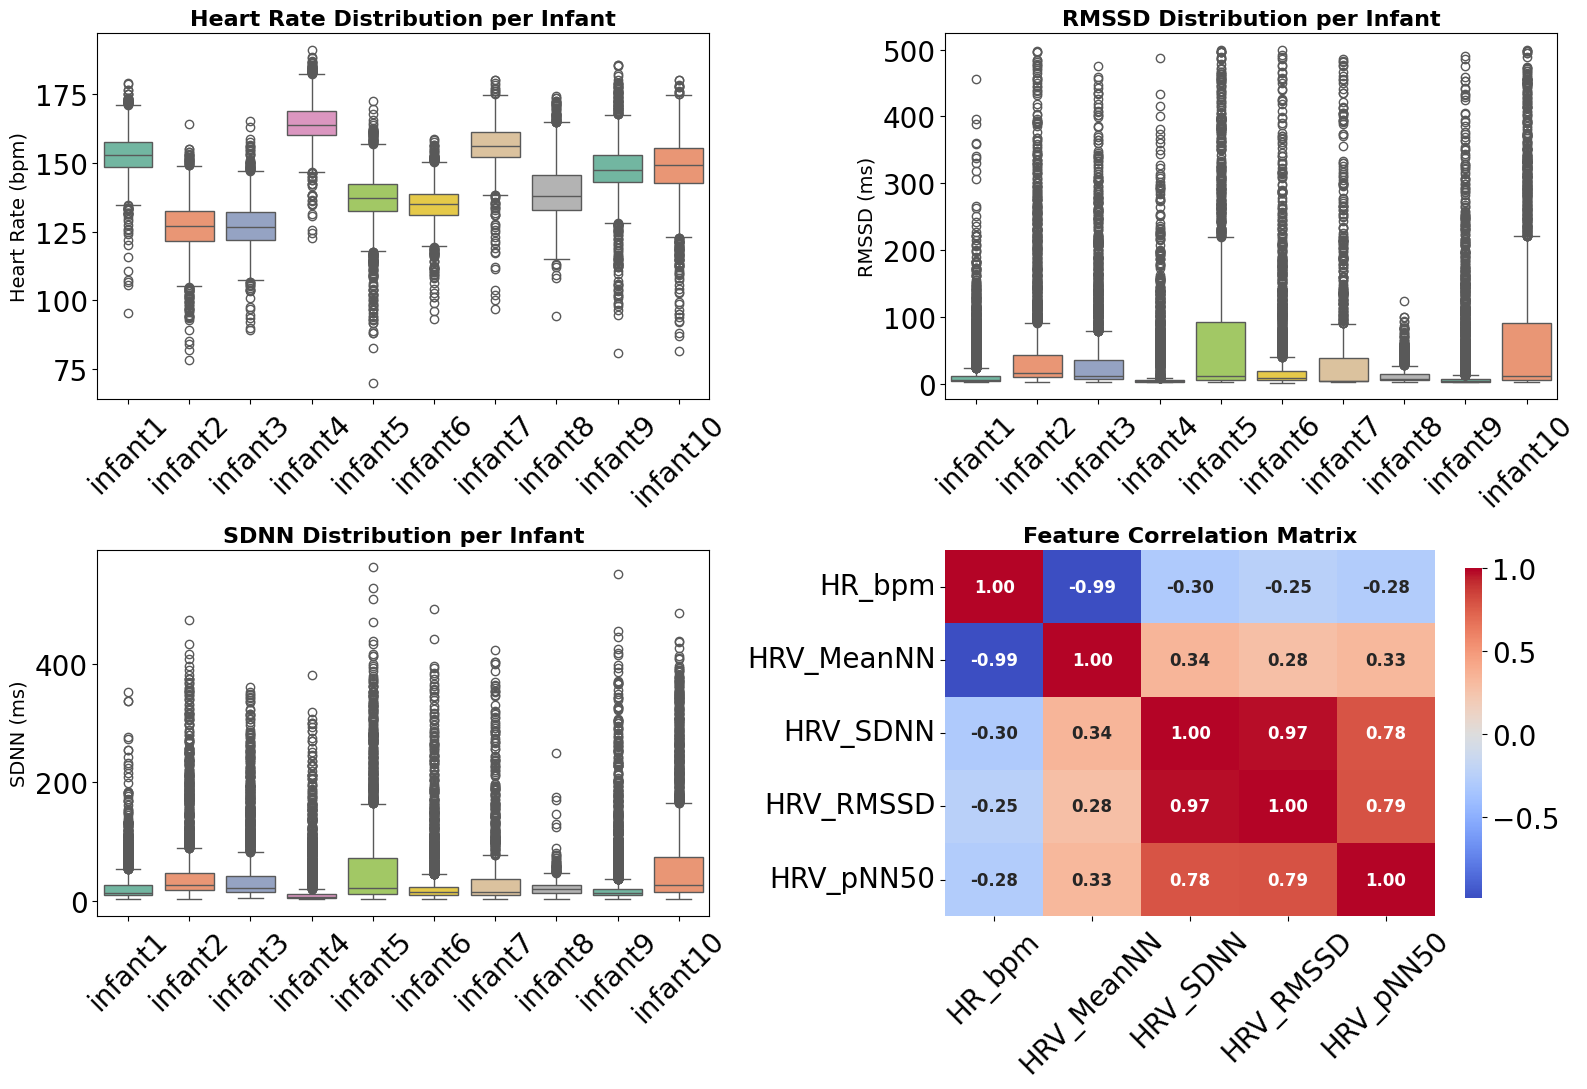

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

combined_df = pd.read_csv(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\all_infants_hrv_features_clean.csv'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# -----------------------------
# 1. Heart Rate Distribution
# -----------------------------
combined_df['HR_bpm'] = 60000 / combined_df['HRV_MeanNN']

sns.boxplot(
    data=combined_df,
    x='infant_id',
    y='HR_bpm',
    ax=axes[0,0],
    palette='Set2'
)

axes[0,0].set_title(
    'Heart Rate Distribution per Infant',
    fontsize=16,
    fontweight='bold'
)
axes[0,0].set_xlabel('', fontsize=14)
axes[0,0].set_ylabel('Heart Rate (bpm)', fontsize=14)

axes[0,0].tick_params(axis='x', rotation=45, labelsize=20)
axes[0,0].tick_params(axis='y', labelsize=20)

# -----------------------------
# 2. RMSSD Distribution
# -----------------------------
sns.boxplot(
    data=combined_df,
    x='infant_id',
    y='HRV_RMSSD',
    ax=axes[0,1],
    palette='Set2'
)

axes[0,1].set_title(
    'RMSSD Distribution per Infant',
    fontsize=16,
    fontweight='bold'
)
axes[0,1].set_xlabel('', fontsize=14)
axes[0,1].set_ylabel('RMSSD (ms)', fontsize=14)

axes[0,1].tick_params(axis='x', rotation=45, labelsize=20)
axes[0,1].tick_params(axis='y', labelsize=20)

# -----------------------------
# 3. SDNN Distribution
# -----------------------------
sns.boxplot(
    data=combined_df,
    x='infant_id',
    y='HRV_SDNN',
    ax=axes[1,0],
    palette='Set2'
)

axes[1,0].set_title(
    'SDNN Distribution per Infant',
    fontsize=16,
    fontweight='bold'
)
axes[1,0].set_xlabel('', fontsize=14)
axes[1,0].set_ylabel('SDNN (ms)', fontsize=14)

axes[1,0].tick_params(axis='x', rotation=45, labelsize=20)
axes[1,0].tick_params(axis='y', labelsize=20)

# -----------------------------
# 4. Correlation Matrix
# -----------------------------
corr_cols = [
    'HR_bpm',
    'HRV_MeanNN',
    'HRV_SDNN',
    'HRV_RMSSD',
    'HRV_pNN50'
]

corr = combined_df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'fontsize':12, 'fontweight':'bold'},
    cbar_kws={'shrink':0.9},
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Feature Correlation Matrix',
    fontsize=16,
    fontweight='bold'
)

axes[1,1].tick_params(axis='x', rotation=45, labelsize=20)
axes[1,1].tick_params(axis='y', rotation=0, labelsize=20)

# Increase colorbar tick size
cbar = axes[1,1].collections[0].colorbar
cbar.ax.tick_params(labelsize=20)

plt.tight_layout()

plt.savefig(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\cross_infant_eda_new.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()